In [7]:
import dai
import pandas as pd

bsd = '2024-01-01'
sd = '2025-01-01'
ed = '2026-05-01'

sql = """
SELECT
    date, instrument,
    close/m_lag(close, 1) as factor,
    close/m_lag(close, 2) as factor2,
    close/m_lag(close, 3) as factor3,
    close/m_lag(close, 4) as factor4,
    close/m_lag(close, 5) as factor5,
    close/m_lag(close, 6) as factor6,
    close/m_lag(close, 7) as factor7,
    close/m_lag(close, 8) as factor8,
    close/m_lag(close, 9) as factor9,
    close/m_lag(close, 10) as factor10,
FROM cn_stock_bar1d
"""

df = dai.query(sql, filters={'date': [bsd, ed]}).df()
df = df[(df['date']>=sd) & (df['date']<=ed)]

index_df = dai.query(
    "SELECT date, member_code as instrument FROM cn_stock_index_component WHERE instrument = '000852.SH'",
    filters={"date": [sd, ed]},
).df()

df = pd.merge(df, index_df, how='right', on=['date', 'instrument'])

In [8]:
import os
import sys
path = '/home/aiuser/work/workspace/BigAlpha/eval/76ad3f56-ec2b-431a-890e-139a7f4bbcba/src/bigalpha_factorminer'
if path not in sys.path:
    sys.path.append(path)

In [9]:
from dataprocess.datachecker import DataCheck
from dataprocess.dataprocess import DataProcess
DataCheck(sd, ed).validate(df)
pdf = DataProcess(sd, ed).validate(df)

[2026-06-09 11:45:22] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'factor2', 'factor3', 'factor4', 'factor5', 'factor6', 'factor7', 'factor8', 'factor9', 'factor10']


[2026-06-09 11:45:22] [info     ] 通过：instrument 格式检查
[2026-06-09 11:45:22] [info     ] 通过：factor 有限值检查（禁止 inf/-inf）
[2026-06-09 11:45:22] [info     ] 通过：时间范围检查
[2026-06-09 11:45:22] [info     ] 通过：交易日完整性检查
[2026-06-09 11:45:22] [info     ] 通过：唯一性检查
[2026-06-09 11:45:22] [info     ] 通过：股票池范围检查（中证1000历史成分）
[2026-06-09 11:45:22] [info     ] 通过：覆盖度检查（每交易日缺失率<=40%）
[2026-06-09 11:45:22] [info     ] 启动因子预处理                        factor_cols=['factor', 'factor2', 'factor3', 'factor4', 'factor5', 'factor6', 'factor7', 'factor8', 'factor9', 'factor10'] rows=320000
[2026-06-09 11:45:22] [info     ] inf 处理, 耗时: 0.0123 秒
[2026-06-09 11:45:23] [info     ] 去极值, 耗时: 0.1425 秒
[2026-06-09 11:45:23] [info     ] 标准化, 耗时: 0.1352 秒
[2026-06-09 11:46:15] [info     ] 风格剔除(取残差), 耗时: 52.7515 秒


[2026-06-09 11:46:16] [info     ] 开始单因子分析                        benchmark=中证1000 end_date=2026-05-01 factor_name=factor group_num=10 input_rows=320000 start_date=2025-01-01
[2026-06-09 11:46:16] [info     ] 加载每日收益数据完成                     end_date=2026-05-01 rows=1777531 start_date=2025-01-01
[2026-06-09 11:46:17] [warning  ] 合并因子与每日收益后存在缺失                 missing_rows=2465 total_rows=320000
[2026-06-09 11:46:17] [info     ] 因子数据与每日收益合并完成                  factor_rows=320000 merged_rows=320000
[2026-06-09 11:46:17] [info     ] 合并相关数据, 耗时: 0.5323 秒
[2026-06-09 11:46:17] [info     ] 因子分组完成                         group_num=10 input_rows=320000 output_rows=309118
[2026-06-09 11:46:17] [info     ] 因子分组, 耗时: 0.8343 秒
[2026-06-09 11:46:17] [info     ] 加载基准指数收益数据完成                   benchmark=中证1000 instrument=000852.SH rows=327
[2026-06-09 11:46:18] [info     ] 分组累计收益计算完成                     benchmark=中证1000 trading_days=320
[2026-06-09 11:46:18] [info     ] 分组收益与累计收益, 耗时: 0.1733 秒
[2026-06-0

时段,区间,IC
covid_2020,2020-02-03 ~ 2020-03-31,nan
micro_cap_2024,2024-01-15 ~ 2024-02-08,nan
policy_rally_2024,2024-09-24 ~ 2024-10-08,nan
tariff_2025,2025-04-07 ~ 2025-04-30,-0.0211

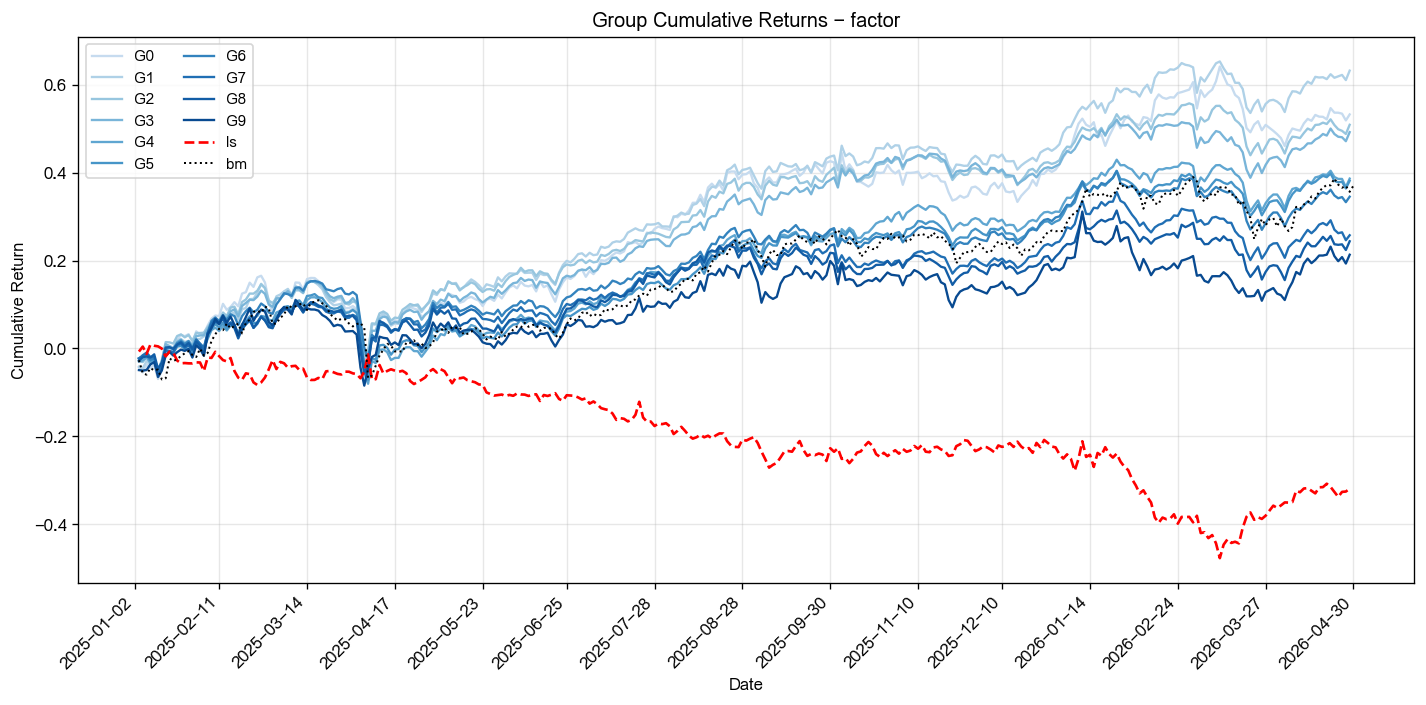
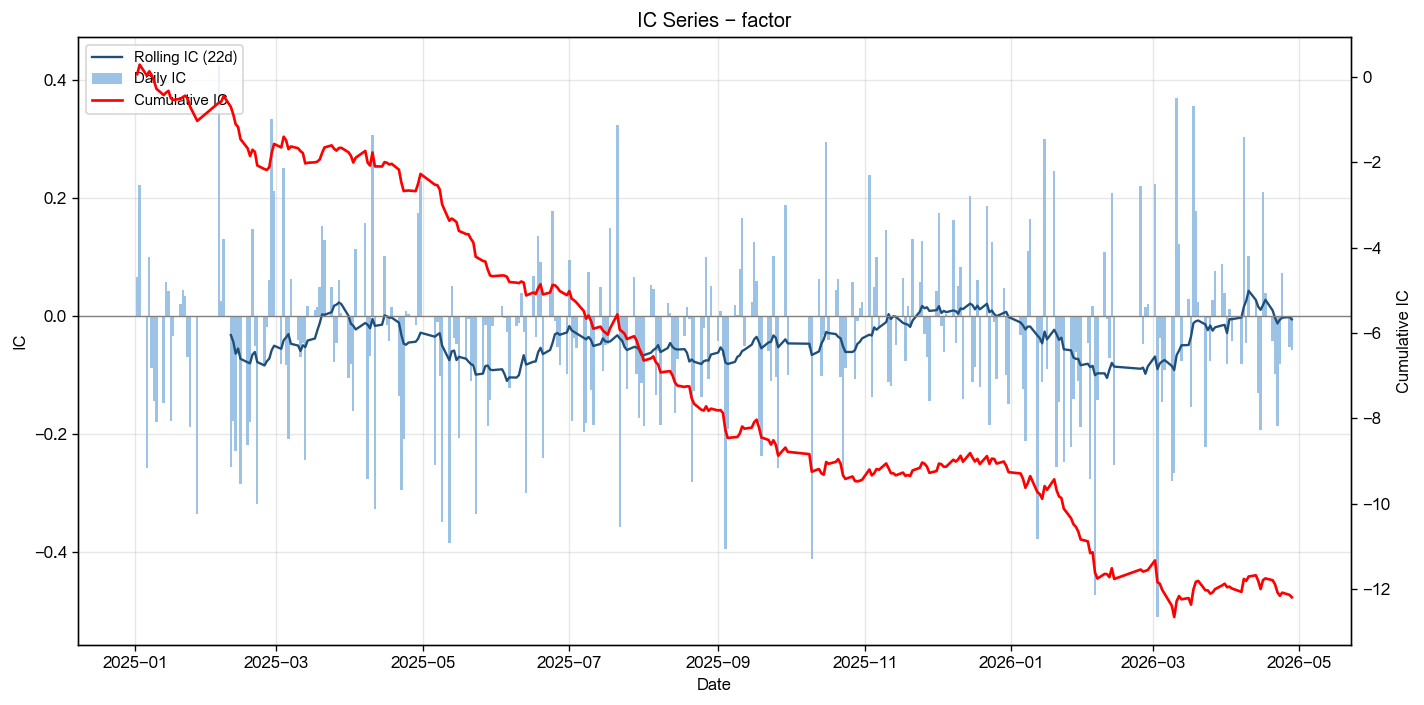
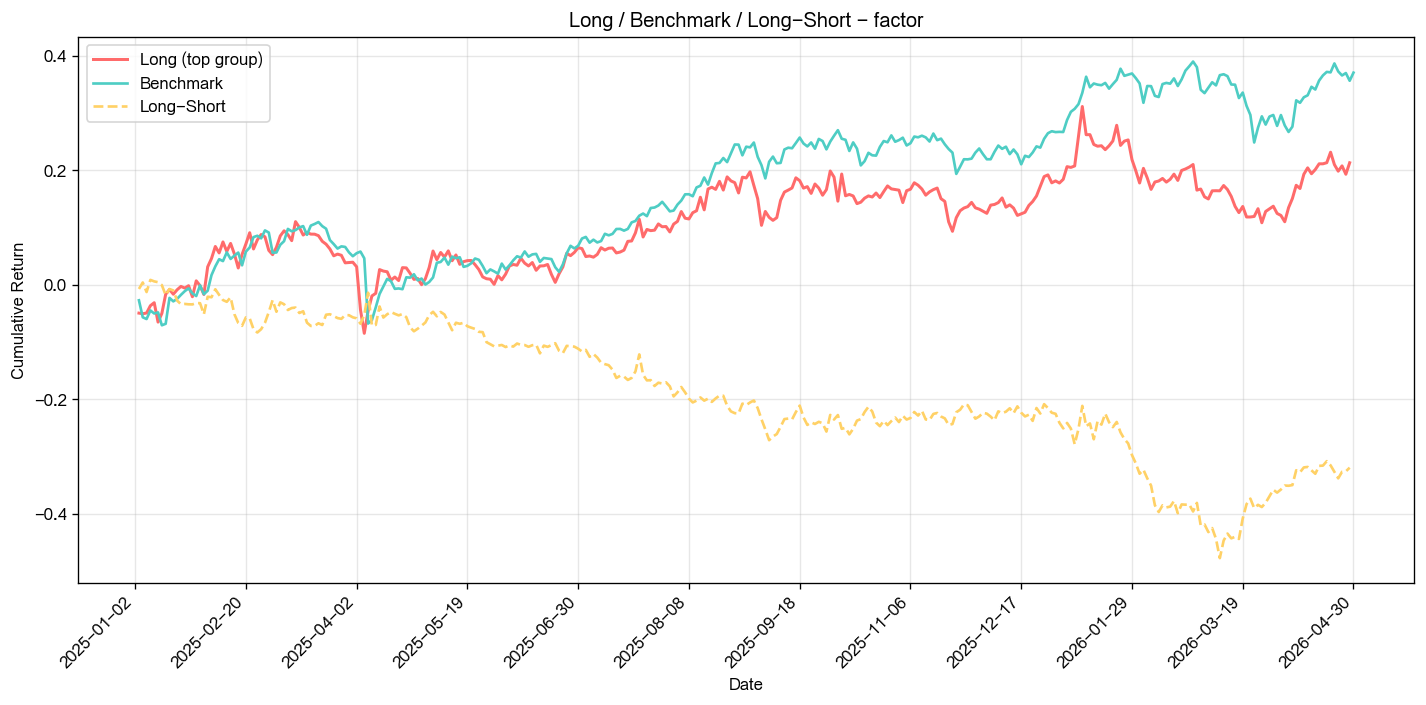
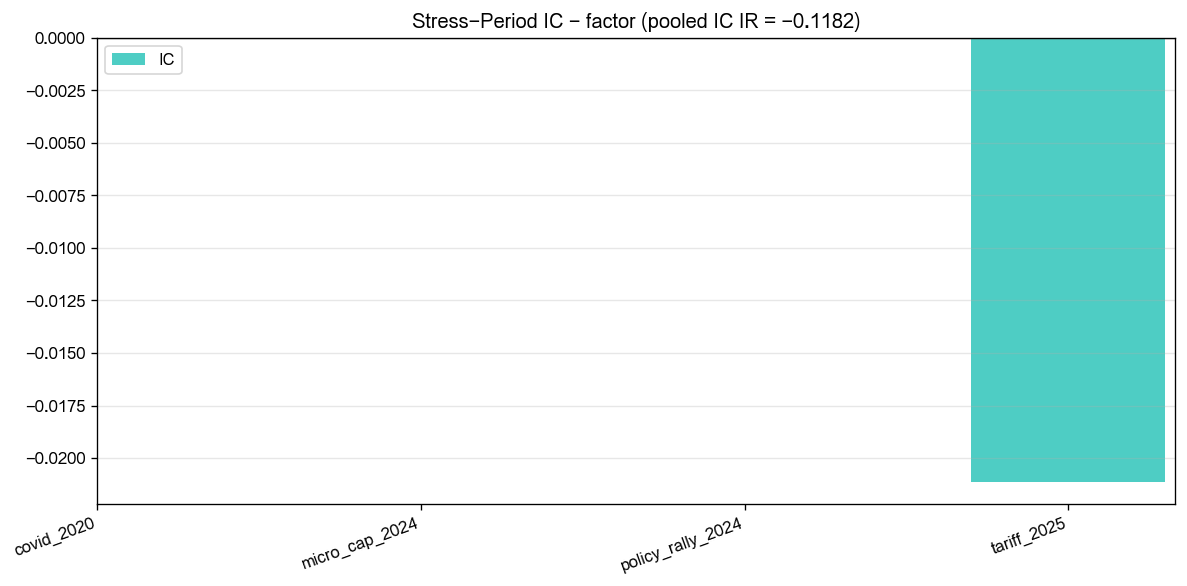

[2026-06-09 11:46:19] [info     ] HTML 报告渲染完成, 耗时: 0.7869 秒      factor_name=factor


In [10]:
from factoranalyze import FactorAnalyze
fa_res = FactorAnalyze(sd, ed).score(df[['date', 'instrument', 'factor']])

[2026-06-09 11:46:19] [info     ] 开始 Elastic Net 滚动回归            alpha=0.001 end_date=2026-05-01 factor_count=10 input_rows=320000 l1_ratio=0.5 start_date=2025-01-01 step=20 window=60
[2026-06-09 11:46:19] [info     ] 加载 T+1 收益数据完成                  end_date=2026-05-01 instrument_count=1211 rows=389603 start_date=2025-01-01
[2026-06-09 11:46:19] [warning  ] 合并后存在缺失，已剔除                    dropped_rows=5303 merged_rows=320000
[2026-06-09 11:46:20] [info     ] 因子面板与 T+1 收益合并 + 截面 z-score 完成 factor_count=10 factor_panel_rows=320000 output_rows=314697
[2026-06-09 11:46:20] [info     ] 合并数据 + 截面 z-score, 耗时: 1.0923 秒
[2026-06-09 11:46:21] [info     ] 滚动 Elastic Net 拟合完成            failed=0 skipped=0 step=20 total_days=320 window=60 window_records=14
[2026-06-09 11:46:21] [info     ] 滚动 Elastic Net 拟合, 耗时: 1.6005 秒
[2026-06-09 11:46:22] [info     ] ModelScore 计算完成                factor_count=10 window_records=14
[2026-06-09 11:46:22] [info     ] ModelScore 聚合, 耗时: 0.0545 秒
[2026-06-09 11:46:22

factor,ModelScore,mean(|w|),std(|w|),selection_rate
factor2,1.4813,0.0101,0.0068,0.8571
factor5,1.4013,0.0198,0.0142,1.0000
factor,1.2347,0.0096,0.0078,0.9286
factor8,1.1651,0.0151,0.0129,0.8571
factor3,1.1135,0.0086,0.0077,0.9286
factor4,1.0696,0.0092,0.0086,0.8571
factor7,1.0130,0.0132,0.0130,0.7857
factor9,0.9834,0.0118,0.0120,0.7857
factor6,0.9822,0.0189,0.0193,0.9286
factor10,0.9656,0.0077,0.0080,0.7857

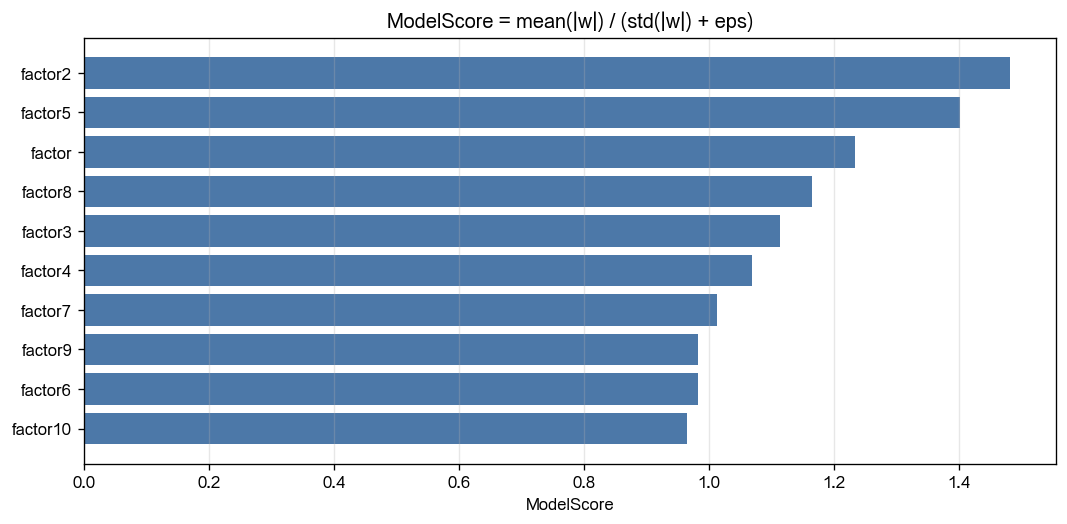
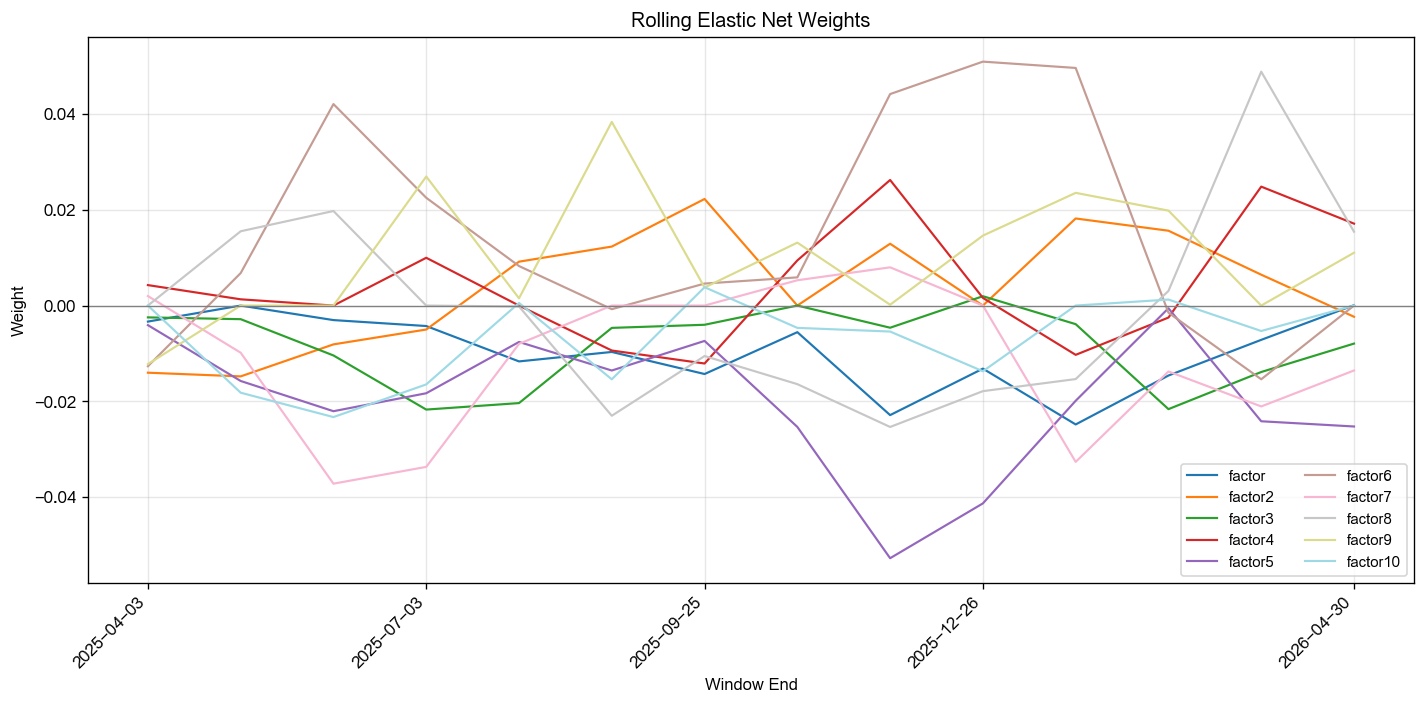
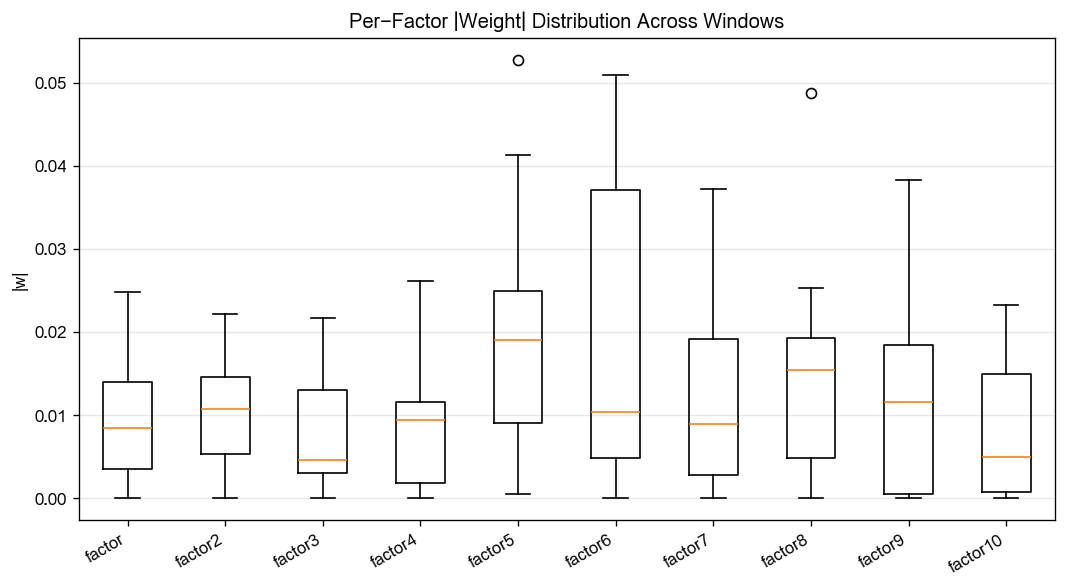
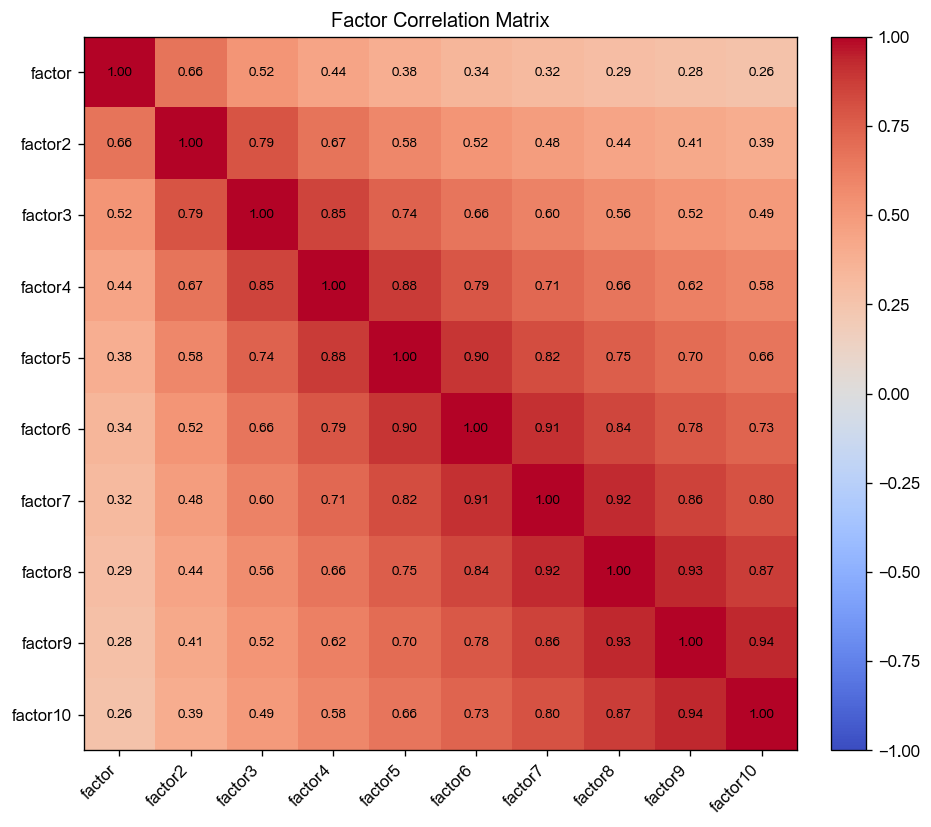

[2026-06-09 11:46:22] [info     ] HTML 报告渲染完成, 耗时: 0.6228 秒      factor_count=10


In [11]:
from regmodel import ElasticNetRegress

reg = ElasticNetRegress(sd, ed)
reg_res = reg.score(pdf)